# Zero-Inflated Poisson Modeling of NCAA Postseason Awards

**Authors:** Kyle Bresko, Charles Lane, Kaleb Treangen

**Course:** DATA 4990 — Capstone

**Department:** School of Data Science and Analytics, Kennesaw State University

**Term:** Spring 2026

---

This notebook contains the analysis code for our capstone project. We model individual player award counts in NCAA Conference USA men's basketball using game-level box score statistics. A Zero-Inflated Poisson (ZIP) regression is employed to handle the excess zeros inherent in award count data, and model performance is evaluated against several baseline regressors using Spearman rank correlation.

# Summary

## Objective
This project predicts individual player award counts for NCAA Conference USA men's basketball using game-level box score statistics. The goal is to identify which statistical performance metrics best predict end-of-season award recognition.

## Data
- **Box scores** were collected via the ncaahoopR R package for three Conference USA seasons: 2023-24, 2024-25, and 2025-26.
- **Awards** data was gathered from conference award announcements for the same seasons.
- Player names were normalized and matched across both sources. Coach awards were excluded.

## Feature Engineering
- Per-game statistics were aggregated at the player-season level, including points, rebounds, assists, steals, blocks, field goals, free throws, and turnovers.
- Derived features include shooting efficiency, usage rate, and team-level totals (FGA, FTA, TOV).
- Features were standardized using StandardScaler prior to modeling.

## Train/Test Split
- **Training:** 2023-24 and 2024-25 seasons
- **Testing:** 2025-26 season

## Modeling
- Several regression models were evaluated via grid search with cross-validation, including Linear Regression, Poisson Regression, Ridge, Lasso, Random Forest, Gradient Boosting, and KNN.
- A **Zero-Inflated Poisson (ZIP)** model was selected as the primary model to account for the large number of players who receive zero awards (excess zeros in the target distribution).
- Model diagnostics included VIF checks for multicollinearity and a dispersion test comparing Poisson vs. Negative Binomial assumptions.

## Evaluation
- Models were compared using Spearman rank correlation, which measures how well predicted values preserve the relative ordering of players by award count.
- The ZIP model was benchmarked against the sklearn regression candidates.
- Residual plots and actual-vs-predicted scatter plots were used for visual assessment.

## Predictions and Analysis
- The ZIP model generated predicted award counts for all players in the 2025-26 test season.
- Rolling prediction windows and games-to-date analyses tracked how player rankings evolved over the course of the season.
- Key players such as R. Johnson, Z. Cleveland, C. Bliss, and K. Natt were profiled across game windows to observe prediction stability.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.model_selection import GridSearchCV

# Models (Regression)
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


# Models (Classification)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    mean_absolute_error, r2_score, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, average_precision_score, root_mean_squared_error
)

from adjustText import adjust_text

# Config

In [2]:
%matplotlib inline

# For reproducibility in models that accept random_state
RANDOM_STATE = 42

# Load Data

### Data Sources
- Boxscore information was gathered using R module ncaahoopR available at https://github.com/lbenz730/ncaahoopR
- Award Count was gathered from counting number of awards based on https://www.sports-reference.com/cbb/awards/

In [3]:
# Define a map for both school names and what seasons they played
# We use this to determine what teams are in conference usa for each season.

schools = pd.DataFrame({
    "School": [
        "FIU", "Jacksonville St", "LA Tech", "Liberty", "Mid Tennessee",
        "New Mexico St", "Sam Houston", "UTEP", "W Kentucky",
        "Kennesaw State", "Delaware", "Missouri State"
    ],
    "23-24": [
        True, True, True, True, True,
        True, True, True, True,
        False, False, False
    ],
    "24-25": [
        True, True, True, True, True,
        True, True, True, True,
        True, False, False
    ],
    "25-26": [
        True, True, True, True, True,
        True, True, True, True,
        True, True, True
    ]
})

display(schools)

,School,23-24,24-25,25-26
0,FIU,True,True,True
1,Jacksonville St,True,True,True
2,LA Tech,True,True,True
3,Liberty,True,True,True
4,Mid Tennessee,True,True,True
5,New Mexico St,True,True,True
6,Sam Houston,True,True,True
7,UTEP,True,True,True
8,W Kentucky,True,True,True
9,Kennesaw State,False,True,True


### Import Boxscores

In [4]:
# This function takes a string for the desired season
# parameter two is the map created in the previous cell
def import_season(season, schools):
    boxscores = {}
    for school in schools['School'][schools[season]]:
        boxscores[school] = pd.read_csv(f'../data/boxscores/{school}_20{season}.csv')
        print(f"Season {season} for \"{school}\" imported.")
    boxscores_all = pd.concat(boxscores.values(), ignore_index=True)
    return boxscores_all

In [5]:
# import the boxscores for target seasons
boxscores_24 = import_season('23-24', schools)
boxscores_25 = import_season('24-25', schools)
boxscores_26 = import_season('25-26', schools)

Season 23-24 for "FIU" imported.
Season 23-24 for "Jacksonville St" imported.
Season 23-24 for "LA Tech" imported.
Season 23-24 for "Liberty" imported.
Season 23-24 for "Mid Tennessee" imported.
Season 23-24 for "New Mexico St" imported.
Season 23-24 for "Sam Houston" imported.
Season 23-24 for "UTEP" imported.
Season 23-24 for "W Kentucky" imported.
Season 24-25 for "FIU" imported.
Season 24-25 for "Jacksonville St" imported.
Season 24-25 for "LA Tech" imported.
Season 24-25 for "Liberty" imported.
Season 24-25 for "Mid Tennessee" imported.
Season 24-25 for "New Mexico St" imported.
Season 24-25 for "Sam Houston" imported.
Season 24-25 for "UTEP" imported.
Season 24-25 for "W Kentucky" imported.
Season 24-25 for "Kennesaw State" imported.
Season 25-26 for "FIU" imported.
Season 25-26 for "Jacksonville St" imported.
Season 25-26 for "LA Tech" imported.
Season 25-26 for "Liberty" imported.
Season 25-26 for "Mid Tennessee" imported.
Season 25-26 for "New Mexico St" imported.
Season 25-26

In [6]:
# Check the dimensions of the imports
for boxs in [(boxscores_24, '24'), (boxscores_25, '25'), (boxscores_26,'26')]:
    print("-"*10 +" Boxscores '" + boxs[1] + " " + "-"*10)
    print(f"Features:\t{boxs[0].shape[1]}")
    print(f"Observations:\t{boxs[0].shape[0]}")
    print()

---------- Boxscores '24 ----------
Features:	23
Observations:	3049

---------- Boxscores '25 ----------
Features:	23
Observations:	3325

---------- Boxscores '26 ----------
Features:	23
Observations:	3866



### Combine Boxscores

In [7]:
# Combine the seasons for EDA and later transformations
# but must retain season for train/validate/test later
boxscores_24['season'] = "2023-24"
boxscores_25['season'] = "2024-25"
boxscores_26['season'] = "2025-26"

# combine
boxscores = pd.concat([boxscores_24, boxscores_25, boxscores_26], ignore_index=True)
print(f"Features:\t{boxscores.shape[1]}")
print(f"Observations:\t{boxscores.shape[0]}")
print()
# display(boxscores.sample(5))

Features:	24
Observations:	10240



### Import Awards

In [8]:
awards_24 = pd.read_csv(f'../data/awards/conferenceusa_awards_2023-24.csv')
awards_25 = pd.read_csv(f'../data/awards/conferenceusa_awards_2024-25.csv')
awards_26 = pd.read_csv(f'../data/awards/conferenceusa_awards_2025-26.csv')

In [9]:
for awards in [(awards_24, '24'), (awards_25, '25'), (awards_26, '26')]:
    print("-"*10 +" Awards '" + awards[1] + " " + "-"*10)
    print(f"Features:\t{awards[0].shape[1]}")
    print(f"Observations:\t{awards[0].shape[0]}")
    print()

---------- Awards '24 ----------
Features:	6
Observations:	36

---------- Awards '25 ----------
Features:	6
Observations:	36

---------- Awards '26 ----------
Features:	6
Observations:	37



### Combine Awards

In [10]:
# Combine the seasons for EDA and later transformations
awards = pd.concat([awards_24, awards_25, awards_26], ignore_index=True)

# rename "Year Won" to match "season"
awards.rename(columns={"Year Won": "season"}, inplace=True)

print(f"Features:\t{awards.shape[1]}")
print(f"Observations:\t{awards.shape[0]}")
print()

Features:	6
Observations:	109



# Clean Data

## Missing Values

In [11]:
boxscores_missing_count = boxscores.isna().sum()
print("Features with missing values:")
boxscores_missing_count[boxscores_missing_count > 0]


Features with missing values:


Series([], dtype: int64)

In [12]:
awards_missing_count = awards.isna().sum()
print("Features with missing values:")
awards_missing_count[awards_missing_count > 0]

Features with missing values:


Subgroup    64
dtype: int64

Subgroup has missing values because not all awards have a subgroup by design. We will start by simply using counts of awards, and so missing subgroups are not an issue.
Example:
- For Men's All-Conference USA Winners, Subgroup = 1st Team, 2nd Team, or 3rd Team
- For Men's Conference USA Defensive Player of the Year Winners, No subgroup as only one award

## Duplicated Data

In [13]:
def check_duplicates(df):
    dupes = df.duplicated()
    counts = dupes.sum()
    if counts > 0:
        print(f"{counts} duplicated rows found")
    else:
        print("No duplicated rows found")
    return df[dupes]

In [14]:
check_duplicates(boxscores)

No duplicated rows found


,player_id,player,MIN,PTS,FGM,FGA,3PTM,3PTA,FTM,FTA,...,BLK,OREB,DREB,PF,team,opponent,home,starter,game_id,season


In [15]:
check_duplicates(awards)

No duplicated rows found


,Player Name,School,Conference,Award Name,Subgroup,season


## Remove Coach Awards

In [16]:
print("Before removing coach awards")
print(f"Features:\t{awards.shape[1]}")
print(f"Observations:\t{awards.shape[0]}")
print()
awards = awards[~awards["Award Name"].str.contains("coach", case=False, na=False)]

print("After removing coach awards")
print(f"Features:\t{awards.shape[1]}")
print(f"Observations:\t{awards.shape[0]}")

Before removing coach awards
Features:	6
Observations:	109

After removing coach awards
Features:	6
Observations:	105


## Normalize Player Names

In [17]:
def normalize(name):
    # first letter of first word, ignoring punctuation
    # second word = letters only
    m = re.search(r"^\s*([A-Za-z])[A-Za-z''.-]*\s+([A-Za-z-]+)", name)
    if not m:
        print(f"Unable to handle {name}")
        return None
    return (m.group(1) + m.group(2)).lower()

In [18]:
award_players = awards['Player Name'].unique()
awards_players_normal = list()
print("Name Conflicts for Awards (like a jr and sr):")
for name in award_players:
    to_be_added = normalize(name)
    if to_be_added in awards_players_normal:
        print(f"Conflict with {name}")
    else:
        awards_players_normal.append(to_be_added)

Name Conflicts for Awards (like a jr and sr):


In [19]:
boxscore_players = boxscores['player'].unique()
boxscore_players_normal = list()
print("Name Conflicts for Boxscores (like a jr and sr):")
for name in boxscore_players:
    to_be_added = normalize(name)
    if to_be_added in boxscore_players_normal:
        print(f"Conflict with {name}")
    else:
        boxscore_players_normal.append(to_be_added)

Name Conflicts for Boxscores (like a jr and sr):
Conflict with T. Horton III


Conflict detected for T. Horton III and T. Horton
This is the same player for all seasons for UTEP
Source: https://www.sports-reference.com/cbb/players/trey-horton-1.html

In [20]:
for name in awards_players_normal:
    if name not in boxscore_players_normal:
        print(f"Award name '{name}' not found in boxscores")

Award name 'ypowell' not found in boxscores


Conflict detected for Y. Powell
There are no players on UTEP for 2023-24 with the name Z. Powell, but Yazid Powell is on the roster.
Source: https://www.sports-reference.com/cbb/schools/texas-el-paso/men/2024.html

In [21]:
boxscores.loc[boxscores['player'] == 'Z. Powell', 'player'] = 'Y. Powell'

In [22]:
# to be able to apply to a pandas col/row we need a version that accepts Series input
def normalize_row(row_orig):
    row = row_orig.copy() # to make sure we are not in a View
    for i in range(0,len(row)):
        m = re.search(r"^\s*([A-Za-z])[A-Za-z''.-]*\s+([A-Za-z-]+)", row.iloc[i])
        if not m:
            row.iloc[i] = "ERROR: " + row.iloc[i]
        else:
            row.iloc[i] = (m.group(1) + m.group(2)).lower()
    return row

In [23]:
# add a  normalized name column to each dataframe to join on
awards['pname'] = normalize_row(awards['Player Name'])
boxscores['pname'] = normalize_row(boxscores['player'])

## Map Opponent to Conference

In [24]:
# we created a csv with team name, season, and conference
opp_to_conf_csv = pd.read_csv('../data/maps/opponent_to_conference.csv')
opponent_to_conference_map = opp_to_conf_csv.melt(
    id_vars='opponent',
    var_name='season',
    value_name='opp_conf'
)

In [25]:
# this creates a feature that holds the opponent conference
boxscores = boxscores.merge(
    opponent_to_conference_map,
    on=['opponent', 'season'],
    how='left'
)

## Define Schemas

In [26]:
# check if team names are conistent across data sources, then save a list
print("Names Consistent:", set(boxscores['team'].unique()) == set(awards['School'].unique()))
all_team_names = list(boxscores['team'].unique())

Names Consistent: True


In [27]:
all_opponent_conferences = list(opponent_to_conference_map['opp_conf'].unique())

# Feature Engineering

## Split seasons into training and testing
- Seasons 2023-24 and 2024-25 → train
- Seasons 2025-26 → test

In [28]:
train_boxscores = boxscores[boxscores['season'].isin(['2023-24', '2024-25'])]
test_boxscores  = boxscores[boxscores['season'] == '2025-26']

# quick sanity check
print("boxscores shape:", boxscores.shape)
print("train_boxscores shape:", train_boxscores.shape)
print("test_boxscores shape:", test_boxscores.shape)

boxscores shape: (10240, 26)
train_boxscores shape: (6374, 26)
test_boxscores shape: (3866, 26)


In [29]:
train_awards = awards[awards['season'].isin(['2023-24', '2024-25'])]
test_awards  = awards[awards['season'] == '2025-26']

# quick sanity check
print("awards shape:", awards.shape)
print("train_awards shape:", train_awards.shape)
print("test_awards shape:", test_awards.shape)

awards shape: (105, 7)
train_awards shape: (70, 7)
test_awards shape: (35, 7)


## Create 'missed' features

In [30]:
# missed shots
def add_shooting_missed(df_orig):
    df = df_orig.copy()
    df['fg_missed']  = df['FGA']  - df['FGM']
    df['tp_missed']  = df['3PTA']  - df['3PTM']
    df['ft_missed']  = df['FTA']  - df['FTM']
    return df

In [31]:
train_boxscores = add_shooting_missed(train_boxscores)
test_boxscores = add_shooting_missed(test_boxscores)

## Aggregate Train Boxscores

In [32]:
def aggregate_player_season(df_orig):
    df = df_orig.copy()

    # filter out people with 0 minutes and 0 pts ?

    games_per_season = df.groupby(['pname','season']).size()
    # Conference frequencies
    cusa_games = (
        df[df['opp_conf'] == 'C-USA']
        .groupby(['pname','season'])
        .size()
    )
    # Rename columns to a clean prefix
    cusa_games = cusa_games.reindex(games_per_season.index, fill_value=0)

    conf_freq = pd.DataFrame({
        'in_conference_rate': cusa_games / games_per_season
    }).reset_index()
    
    aggr = df.groupby(['pname', 'season']).agg(
        min_total    = ('MIN', 'sum'),
        min_pg       = ('MIN', 'mean'),
        pts_pg       = ('PTS', 'mean'),
        fg_made_pg   = ('FGM', 'mean'),
        fg_attempted_pg = ('FGA', 'mean'),
        fg_missed_pg = ('fg_missed', 'mean'),
        tp_made_pg   = ('3PTM', 'mean'),
        tp_attempted_pg = ('3PTA', 'mean'),
        tp_missed_pg = ('tp_missed', 'mean'),
        ft_made_pg   = ('FTM', 'mean'),
        ft_attempted_pg = ('FTA', 'mean'),
        ft_missed_pg = ('ft_missed', 'mean'),
        ast_pg       = ('AST', 'mean'),
        tov_pg       = ('TO', 'mean'),
        stl_pg       = ('STL', 'mean'),
        blk_pg       = ('BLK', 'mean'),
        oreb_pg      = ('OREB', 'mean'),
        dreb_pg      = ('DREB', 'mean'),
        pf_pg        = ('PF', 'mean'),
        team         = ('team', lambda x: x.mode().iat[0]),
        home_rate    = ('home', 'mean'),
        starter_rate = ('starter', 'mean'),
        ).reset_index()
    aggr['fg_percentage_pg'] = (aggr['fg_made_pg'] / aggr['fg_attempted_pg']).fillna(0)
    aggr['tp_percentage_pg'] = (aggr['tp_made_pg'] / aggr['tp_attempted_pg']).fillna(0)
    aggr['ft_percentage_pg'] = (aggr['ft_made_pg'] / aggr['ft_attempted_pg']).fillna(0)
    # aggr = pd.get_dummies(aggr, columns=['team'], prefix='team')
    aggr = aggr.merge(conf_freq, on=['pname','season'], how='left')
    return aggr

In [33]:
def enforce_schema(df_orig, all_team_names, all_conferences):
    df = df_orig.copy()
    
    # # Enforce conference frequency schema
    # for conf in all_conferences:
    #     col = f"conf_{conf}"
    #     if col not in df.columns:
    #         df[col] = 0.0
    
    # Enforce team one-hot schema
    for team in all_team_names:
        col = f"team_{team}"
        if col not in df.columns:
            df[col] = 0
    
    # Sort columns for stability
    df = df.reindex(sorted(df.columns), axis=1)

    # cast to int so the type shows up proper downstream
    team_cols = [f"team_{t}" for t in all_team_names]
    df[team_cols] = df[team_cols].astype(int)

    # drop florida as the reference team, as florida is present in all seasons
    reference_team = [c for c in df.columns if c.startswith("team_Flo")][0]
    df = df.drop(columns=[reference_team])
    
    return df

In [34]:
train_player_season = aggregate_player_season(train_boxscores)
# train_player_season = enforce_schema(train_player_season, all_team_names, all_opponent_conferences)

## Aggregate Test Boxscores

In [35]:
test_player_season = aggregate_player_season(test_boxscores)
# test_player_season = enforce_schema(test_player_season, all_team_names, all_opponent_conferences)
test_player_season.shape

(166, 28)

## Aggregate Train Awards

In [36]:
def aggregate_awards(df_orig):
    df = df_orig.copy()

    # test drops
    df = df[df['Award Name'] != "Men's Conference USA All-Freshman Winners"]

    # Aggregate awards per player-season
    aggr_awards = (
        df
        .groupby(['pname', 'season'])
        .agg(
            award_count=('Award Name', 'count')  # or whatever your award column is
        )
        .reset_index()
    )

    return aggr_awards

In [37]:
train_player_season_awards = aggregate_awards(train_awards)
train_player_season_awards.shape


(40, 3)

## Aggregate Test Awards

In [38]:
test_player_season_awards = aggregate_awards(test_awards)
test_player_season_awards.shape

(23, 3)

## Join Boxscores and Awards

In [39]:
def merge_boxscores_awards(boxscores, awards):
    box = boxscores.copy()
    award = awards.copy()
    merged = box.merge(award, on=['pname', 'season'], how='left')
    merged.loc[merged['award_count'].isna(), 'award_count'] = 0
    return merged

In [40]:
train = merge_boxscores_awards(train_player_season, train_player_season_awards)
train.shape

(266, 29)

In [41]:
test_full_season = merge_boxscores_awards(test_player_season, test_player_season_awards)
test_full_season.shape

(166, 29)

## Create Efficiency

In [42]:
def add_efficiency(df_orig):
    df = df_orig.copy()
    df['eff_pg'] = ( df['pts_pg'] + df['dreb_pg'] + df['oreb_pg'] + df['ast_pg'] + df['stl_pg'] + df['blk_pg'] ) - ((df['fg_attempted_pg'] - df['fg_made_pg'])+(df['ft_attempted_pg'] - df['ft_made_pg'])+(df['tov_pg']))
    return df

In [43]:
train = add_efficiency(train)
test_full_season = add_efficiency(test_full_season)

## Create Usage

In [44]:
#     USG% = 100 * ((FGA + 0.44*FTA + TOV) * (Team MP / 5)) / (MP * (Team FGA + 0.44*Team FTA + Team TOV))

In [45]:
def get_team_totals(df):
    cols = ['min_pg', 'fg_attempted_pg', 'ft_attempted_pg', 'tov_pg']
    team_totals = (
        df.copy().groupby(['team', 'season'])[cols]
          .sum()
          .rename(columns={
              'min_pg': 'team_min_pg',
              'fg_attempted_pg': 'team_fga_pg',
              'ft_attempted_pg': 'team_fta_pg',
              'tov_pg': 'team_tov_pg',
          })
          .reset_index()
    )
    return team_totals


def add_usage(df, team_totals):
    out = df.copy().merge(team_totals, on=['team', 'season'], how='left')

    player_poss = (out['fg_attempted_pg']
                   + 0.44 * out['ft_attempted_pg']
                   + out['tov_pg'])
    team_poss = (out['team_fga_pg']
                 + 0.44 * out['team_fta_pg']
                 + out['team_tov_pg'])

    out['usg_pct'] = 100 * (player_poss * (out['team_min_pg'] / 5)) \
                         / (out['min_pg'] * team_poss)
    return out


In [46]:
train_team_totals = get_team_totals(train)
train = add_usage(train, train_team_totals)

test_team_totals = get_team_totals(test_full_season)
test_full_season = add_usage(test_full_season, test_team_totals)

### Minute Filter (Optional)

In [47]:
filter_by_total_minutes = False
if (filter_by_total_minutes):
    minute_map = train['min_total'] < 250
    print(train[minute_map]['pname'].count())
    print(train.shape)
    train = train[~minute_map].copy()
    print(train.shape)

# Prepare X/y

In [48]:
features = ['dreb_pg',
            'oreb_pg',
            'ast_pg',
            'stl_pg',
            'blk_pg',
            'fg_attempted_pg',
            'fg_made_pg',
            'ft_attempted_pg',
            'ft_made_pg',
            'tov_pg',
            'team_fga_pg',
            'team_fta_pg',
            'team_tov_pg']
features_zero = ['eff_pg']

In [49]:
X_train = train[features]

In [50]:
# model cant handle two teams not playing in season 24 and 25 but in 26
zero_team_cols = [c for c in X_train.columns 
                  if c.startswith("team_") and X_train[c].sum() == 0]
print("training:", zero_team_cols)
X_train = X_train.drop(columns=zero_team_cols)

X_test_full = test_full_season[features]
# TODO: schema issues
X_test_full = X_test_full.drop(columns=zero_team_cols)

y_train = train['award_count']
y_test = test_full_season['award_count']

training: []


In [51]:
# output X_train
X_train.to_csv('../data/traintest/X_train.csv')
# output X_test
X_test_full.to_csv('../data/traintest/X_test.csv')
# output y_train
y_train.to_csv('../data/traintest/y_train.csv')
# output y_test
y_test.to_csv('../data/traintest/y_test.csv')

In [52]:
# quick dispersion check
print("Training: All y_i dispersion check:", np.var(y_train) / np.mean(y_train))
# the zip model will separate zeros and 1s, so out of curiosity we'll check dispersion of nonzeros
print("Training: y_i != 0 dispersion check:",np.var(y_train[y_train != 0]) / np.mean(y_train[y_train != 0]))

Training: All y_i dispersion check: 1.7411027568922308
Training: y_i != 0 dispersion check: 0.4666666666666666


In [53]:
numeric_features = X_train.columns.tolist()
numeric_features == features

True

In [54]:
features_scaler = StandardScaler()
features_scaler.fit(X_train[numeric_features])

X_train_scaled = features_scaler.transform(X_train[numeric_features])
X_test_full_scaled  = features_scaler.transform(X_test_full[numeric_features])

# Evaluate Models

In [55]:
def evaluate_regressor(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
import numpy as np

def precision_at_k(y_true, y_pred, k):
    # indices of top-k predicted values
    top_k_pred = np.argsort(y_pred)[::-1][:k]
    # actual winners (assuming y_true is binary 0/1)
    actual_winners = np.where(y_true == 1)[0]
    hits = np.intersect1d(top_k_pred, actual_winners)
    return len(hits) / k

def recall_at_k(y_true, y_pred, k):
    actual_winners = np.where(y_true == 1)[0]
    if len(actual_winners) == 0:
        return np.nan
    top_k_pred = np.argsort(y_pred)[::-1][:k]
    hits = np.intersect1d(top_k_pred, actual_winners)
    return len(hits) / len(actual_winners)

def average_precision_at_k(y_true, y_pred, k):
    # y_true: binary array (1 = relevant, 0 = not relevant)
    # y_pred: predicted scores (higher = better)
    
    idx = np.argsort(y_pred)[::-1][:k]
    hits = 0
    sum_precisions = 0
    
    for i, index in enumerate(idx, start=1):
        if y_true[index] == 1:
            hits += 1
            sum_precisions += hits / i
    
    return sum_precisions / k


def evaluate_regressor(y_true, y_pred, k=10):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Spearman rank correlation
    rho, _ = spearmanr(y_true, y_pred)

    # Ranking metrics
    p_at_5 = precision_at_k(y_true, y_pred, 5)
    p_at_10 = precision_at_k(y_true, y_pred, 10)
    p_at_15 = precision_at_k(y_true, y_pred, 15)
    p_at_20 = precision_at_k(y_true, y_pred, 20)
    r_at_5 = recall_at_k(y_true, y_pred, 5)
    r_at_10 = recall_at_k(y_true, y_pred, 10)
    r_at_15 = recall_at_k(y_true, y_pred, 15)
    r_at_20 = recall_at_k(y_true, y_pred, 20)
    ap_at_5 = average_precision_at_k(y_true, y_pred, 5)
    ap_at_10 = average_precision_at_k(y_true, y_pred, 5)
    ap_at_15 = average_precision_at_k(y_true, y_pred, 5)
    ap_at_20 = average_precision_at_k(y_true, y_pred, 5)

    return {
        # "MAE": mae,
        # "RMSE": rmse,
        # "R2": r2,
        "SpearmanRho": rho,
        "AP@5": ap_at_5,
        "AP@10": ap_at_10,
        "AP@15": ap_at_15,
        "AP@20": ap_at_20,
        # f"P@5": p_at_5,
        # f"P@10": p_at_10,
        # f"P@15": p_at_15,
        # f"P@20": p_at_20,
        # f"R@5": r_at_5,
        # f"R@10": r_at_10,
        # f"R@15": r_at_15,
        # f"R@20": r_at_20,
    }

## Basic Non-linear Models

In [57]:
# model registry
reg_candidates = {
    "LinearRegression": (
        LinearRegression(),
        {}  # empty grid → GridSearchCV still runs, but no tuning
    ),

    "KNN": (
        KNeighborsRegressor(),
        {"n_neighbors": [3, 7, 15]}
    ),

    "SVR(RBF)": (
        SVR(),
        {"kernel": ["rbf"], "C": [1, 10], "gamma": ["scale", "auto"]}
    ),

    "DecisionTree": (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {"max_depth": [5, 10, 20, None]}
    ),

    "RandomForest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [100, 200]}
    ),

    "MLP": (
        MLPRegressor(max_iter=400, random_state=RANDOM_STATE, early_stopping=True),
        {"hidden_layer_sizes": [(16,), (32,), (16,8), (32,16)]}
    ),

    "Poisson": (
    PoissonRegressor(max_iter=1000, alpha=1.0),
    {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}
    ),
}

In [58]:
reg_results = []
reg_models = {}

for name, (est, grid) in reg_candidates.items():

    # Force GridSearchCV for all models
    model = GridSearchCV(
        estimator=est,
        param_grid=grid,
        cv=3,
        n_jobs=-1,
    )

    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_full_scaled)

    metrics = evaluate_regressor(y_test, pred)

    reg_results.append({
        "Model": name,
        "Best_Params": model.best_params_,
        **metrics
    })

    reg_models[name] = model

In [59]:
reg_df = pd.DataFrame(reg_results)
reg_df_sorted = reg_df.sort_values(by="SpearmanRho").reset_index(drop=True)
reg_df_sorted

,Model,Best_Params,SpearmanRho,AP@5,AP@10,AP@15,AP@20
0,MLP,"{'hidden_layer_sizes': (32,)}",0.348609,0.800000,0.800000,0.800000,0.800000
1,LinearRegression,{},0.472347,0.233333,0.233333,0.233333,0.233333
2,SVR(RBF),"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.493313,0.286667,0.286667,0.286667,0.286667
3,Poisson,{'alpha': 0.1},0.514146,0.483333,0.483333,0.483333,0.483333
4,KNN,{'n_neighbors': 3},0.534896,0.146667,0.146667,0.146667,0.146667
5,RandomForest,{'n_estimators': 200},0.550753,0.543333,0.543333,0.543333,0.543333
6,DecisionTree,{'max_depth': 5},0.571933,0.643333,0.643333,0.643333,0.643333


## Zero-Inflated Poisson

### Statsmodels Zero Inflated Poisson

In [60]:
# to interpret coefficents, wrap the scaled back into df
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

In [61]:
X_test_full_scaled_df = pd.DataFrame(
    X_test_full_scaled,
    columns=X_test_full.columns,
    index=X_test_full.index
)

In [62]:
# Setup reduced inflation features
zero_scaler = StandardScaler()
zero_scaler.fit(train[features_zero])
X_train_zero_scaled = zero_scaler.transform(train[features_zero])
X_test_full_zero_scaled = zero_scaler.transform(test_full_season[features_zero])

X_train_zero_scaled_df = pd.DataFrame(
    X_train_zero_scaled,
    columns=features_zero,
    index=train.index
)

X_test_full_zero_scaled_df = pd.DataFrame(
    X_test_full_zero_scaled,
    columns=features_zero,
    index=test_full_season.index
)

In [63]:
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson

# Add intercepts
X_train_const = sm.add_constant(X_train_scaled_df)
X_train_zero_const = sm.add_constant(X_train_zero_scaled_df)   # can be different features if desired

In [64]:
X_test_full_const = sm.add_constant(X_test_full_scaled_df)
X_test_zero_full_const = sm.add_constant(X_test_full_zero_scaled_df)

In [65]:
zip_model = ZeroInflatedPoisson(
    endog=y_train,
    exog=X_train_const,          # Poisson mean model
    exog_infl=X_train_zero_const, # Zero-inflation (logit) model
    inflation='logit',
)

zip_results = zip_model.fit(method='bfgs', maxiter=500, disp=False)
print(zip_results.summary())

                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:             award_count   No. Observations:                  266
Model:             ZeroInflatedPoisson   Df Residuals:                      252
Method:                            MLE   Df Model:                           13
Date:                 Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4554
Time:                         14:16:51   Log-Likelihood:                -82.481
converged:                        True   LL-Null:                       -151.45
Covariance Type:             nonrobust   LLR p-value:                 5.463e-23
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       1.7966      1.118      1.607      0.108      -0.395       3.988
inflate_eff_pg     -4.4103      1.632     -2.702      0.007      -7.609      -1.212
const              -2.05

### VIF Check

In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df):
    X = df.assign(const=1)
    return pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    )

In [67]:
vifs = compute_vif(X_train)
vifs.sort_values()

team_fga_pg          1.445736
team_fta_pg          1.476068
team_tov_pg          1.934760
blk_pg               2.316670
stl_pg               2.533315
ast_pg               3.358758
oreb_pg              3.944203
dreb_pg              5.570389
tov_pg               6.497074
fg_attempted_pg     26.329322
fg_made_pg          27.868129
ft_made_pg          30.154334
ft_attempted_pg     31.238893
const              194.145008
dtype: float64

### Other Check

In [68]:
endog = y_train.copy()
exog = X_train_const.copy()
infl_vars = X_train_zero_const.copy()

In [69]:
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

zinb_mod = ZeroInflatedNegativeBinomialP(endog, exog, exog_infl=infl_vars).fit()
zinb_mod.summary()

         Current function value: nan
         Iterations: 3
         Function evaluations: 114
         Gradient evaluations: 114


c:\Users\charl\miniforge3\envs\mining\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\charl\miniforge3\envs\mining\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\charl\miniforge3\envs\mining\Lib\site-packages\statsmodels\discrete\discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
c:\Users\charl\miniforge3\envs\mining\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\charl\miniforge3\envs\mining\Lib\site-packages\statsmodels\discrete\discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
c:\Users\charl\miniforge3\envs\mining\Lib\site-packages\statsmodels\discrete\discrete_model.py:39

<class 'statsmodels.iolib.summary.Summary'>
"""
                     ZeroInflatedNegativeBinomialP Regression Results                    
=========================================================================================
Dep. Variable:                       award_count   No. Observations:                  266
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      252
Method:                                      MLE   Df Model:                           13
Date:                           Wed, 29 Apr 2026   Pseudo R-squ.:                     nan
Time:                                   14:16:51   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -150.79
Covariance Type:                       nonrobust   LLR p-value:                       nan
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const    -119.4159        nan        nan        nan         nan         nan
inflate_eff_pg   -191.0763        nan        nan        nan         nan         nan
const              39.2864        nan        nan        nan         nan         nan
dreb_pg            11.4754        nan        nan        nan         nan         nan
oreb_pg            -0.7376        nan        nan        nan         nan         nan
ast_pg             -5.6140        nan        nan        nan         nan         nan
stl_pg              0.6819        nan        nan        nan         nan         nan
blk_pg             -4.8117        nan        nan        nan         nan         nan
fg_attempted_pg   -19.5720        nan        nan        nan         nan         nan
fg_made_pg        -18.4523        nan        nan        nan         nan         nan
ft_attempted_pg    -9.8086        nan        nan        nan         nan         nan
ft_made_pg        -12.2296        nan        nan        nan         nan         nan
tov_pg            -20.8888        nan        nan        nan         nan         nan
team_fga_pg         3.6623        nan        nan        nan         nan         nan
team_fta_pg         4.2780        nan        nan        nan         nan         nan
team_tov_pg         5.9533        nan        nan        nan         nan         nan
alpha             -39.8782        nan        nan        nan         nan         nan
===================================================================================
"""

In [70]:
pois = sm.GLM(endog, exog, family=sm.families.Poisson()).fit()

mu = pois.fittedvalues
resid = (endog - mu)**2 - endog
aux = sm.OLS(resid, sm.add_constant(mu)).fit()
print(aux.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.036
Date:                Wed, 29 Apr 2026   Prob (F-statistic):              0.155
Time:                        14:16:51   Log-Likelihood:                -268.91
No. Observations:                 266   AIC:                             541.8
Df Residuals:                     264   BIC:                             549.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0180      0.044     -0.409      0.6

# Predictions

In [71]:
yhat_mean = zip_results.predict(
    exog=X_test_full_const,
    exog_infl=X_test_zero_full_const,
    which="mean"
)
zip_metrics = evaluate_regressor(y_test, yhat_mean)

In [72]:
new_row = {
    "Model": "ZIP",
    "Best_Params": "infl: ",
    # "MAE": zip_metrics['MAE'],
    # "RMSE": zip_metrics['RMSE'],
    # "R2": zip_metrics['R2'],
    "SpearmanRho": zip_metrics['SpearmanRho'],
    # "P@5": zip_metrics['P@5'],
    # "P@10": zip_metrics['P@10'],
    # "P@15": zip_metrics['P@15'],
    # "P@20": zip_metrics['P@20'],
    # "R@5": zip_metrics['R@5'],
    # "R@10": zip_metrics['R@10'],
    # "R@15": zip_metrics['R@15'],
    # "R@20": zip_metrics['R@20'],
    "AP@5": zip_metrics['AP@5'],
    "AP@10": zip_metrics['AP@10'],
    "AP@15": zip_metrics['AP@15'],
    "AP@20": zip_metrics['AP@20'],
}

In [73]:
reg_df_sorted_zip = reg_df_sorted._append(new_row, ignore_index=True)
reg_df_sorted_zip = reg_df_sorted_zip.sort_values(by="AP@10", ascending=False).reset_index(drop=True)
reg_df_sorted_zip

,Model,Best_Params,SpearmanRho,AP@5,AP@10,AP@15,AP@20
0,MLP,"{'hidden_layer_sizes': (32,)}",0.348609,0.800000,0.800000,0.800000,0.800000
1,DecisionTree,{'max_depth': 5},0.571933,0.643333,0.643333,0.643333,0.643333
2,RandomForest,{'n_estimators': 200},0.550753,0.543333,0.543333,0.543333,0.543333
3,Poisson,{'alpha': 0.1},0.514146,0.483333,0.483333,0.483333,0.483333
4,ZIP,infl:,0.502938,0.353333,0.353333,0.353333,0.353333
5,SVR(RBF),"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.493313,0.286667,0.286667,0.286667,0.286667
6,LinearRegression,{},0.472347,0.233333,0.233333,0.233333,0.233333
7,KNN,{'n_neighbors': 3},0.534896,0.146667,0.146667,0.146667,0.146667


## Rolling Prediction Windows

In [74]:
test_full_season['yhat'] = yhat_mean
prediction_ranks = test_full_season[['pname', 'team', 'yhat', 'award_count']].sort_values('yhat', ascending=False)
prediction_ranks

,pname,team,yhat,award_count
162,zcleveland,Liberty,3.333688e+00,2.0
19,bdecker,Liberty,2.114447e+00,1.0
118,mel,Jacksonville State,2.058942e+00,1.0
124,mosei-bonsu,Missouri State,1.733371e+00,2.0
83,jjones,New Mexico State,1.556813e+00,1.0
...,...,...,...,...
18,bbaffone,Delaware,1.008634e-05,0.0
145,teaglestaff,New Mexico State,7.908004e-06,0.0
127,nnjoku,Delaware,7.150395e-06,0.0
46,dcosby,Kennesaw State,6.716970e-06,0.0


In [75]:
# our top predicted
prediction_ranks['rank'] = prediction_ranks['yhat'].rank(ascending=False)
prediction_ranks['rank_in_team'] = prediction_ranks.groupby("team")["yhat"].rank(ascending=False)
prediction_ranks[:10]

,pname,team,yhat,award_count,rank,rank_in_team
162,zcleveland,Liberty,3.333688,2.0,1.0,1.0
19,bdecker,Liberty,2.114447,1.0,2.0,2.0
118,mel,Jacksonville State,2.058942,1.0,3.0,1.0
124,mosei-bonsu,Missouri State,1.733371,2.0,4.0,1.0
83,jjones,New Mexico State,1.556813,1.0,5.0,1.0
79,jharper,Liberty,1.272409,1.0,6.0,3.0
93,jwest,UTEP,1.195921,0.0,7.0,1.0
75,jfernandez,Delaware,1.153132,0.0,8.0,1.0
149,tmoore,Western Kentucky,1.004023,1.0,9.0,1.0
98,kmetheny,Liberty,0.977520,1.0,10.0,4.0


In [76]:
# top predicted on their team
prediction_ranks[prediction_ranks['rank_in_team'] == 1]

,pname,team,yhat,award_count,rank,rank_in_team
162,zcleveland,Liberty,3.333688,2.0,1.0,1.0
118,mel,Jacksonville State,2.058942,1.0,3.0,1.0
124,mosei-bonsu,Missouri State,1.733371,2.0,4.0,1.0
83,jjones,New Mexico State,1.556813,1.0,5.0,1.0
93,jwest,UTEP,1.195921,0.0,7.0,1.0
75,jfernandez,Delaware,1.153132,0.0,8.0,1.0
149,tmoore,Western Kentucky,1.004023,1.0,9.0,1.0
41,cstephenson,Florida International,0.950659,1.0,11.0,1.0
137,scottle,Kennesaw State,0.924629,0.0,12.0,1.0
141,swykle,Middle Tennessee,0.786493,0.0,15.0,1.0


In [77]:
prediction_ranks[prediction_ranks['award_count'] > 0].sort_values(by="award_count", ascending=False)

,pname,team,yhat,award_count,rank,rank_in_team
132,rjohnson,Kennesaw State,0.533064,3.0,21.0,2.0
100,knatt,Sam Houston,0.260086,3.0,40.0,3.0
162,zcleveland,Liberty,3.333688,2.0,1.0,1.0
124,mosei-bonsu,Missouri State,1.733371,2.0,4.0,1.0
30,cbliss,Delaware,0.794043,2.0,14.0,2.0
118,mel,Jacksonville State,2.058942,1.0,3.0,1.0
19,bdecker,Liberty,2.114447,1.0,2.0,2.0
149,tmoore,Western Kentucky,1.004023,1.0,9.0,1.0
79,jharper,Liberty,1.272409,1.0,6.0,3.0
83,jjones,New Mexico State,1.556813,1.0,5.0,1.0


In [78]:
# lets profile zcleveland

# select an amount of games per player
# how the boxscores come in is chronologically by index
# the gamescore ids are NOT chronological
# as an example for zcleveland specifically:
#   reg non-conf games are games 1 to 10
#   reg conf games are games 11 to 30
#   ctourn is 31 or probably -3
#   nit is 32-33, or probably -2 and -1
def predict_in_window(player_of_interest, games_start, games_end, zip_results, verbose=False):
    # player_of_interest = 'zcleveland'
    # games_start = 1
    # games_end = 5
    # select players
    # player_of_interest = 'scottle'
    # select index 
    mask = test_boxscores['pname'] == player_of_interest
    games_of_interest = test_boxscores[mask].iloc[games_start - 1:games_end]
    if(verbose):
        print(games_of_interest[['team', 'opponent']])
    game_ids_of_interest = games_of_interest['game_id']
    team_of_interest = games_of_interest['team'].unique()[0] # this is one area to improve, we can easily make a new DF to hold team totals
    # aggregate the window
    window_pg = aggregate_player_season(games_of_interest)
    window_pg = add_efficiency(window_pg) # add efficiency
    # to add usage we need the teams, but i dont think we even use the usage stat proper, just the team totals
    mask_game_ids_of_interest = test_boxscores['game_id'].isin(game_ids_of_interest)
    mask_team_of_interest = test_boxscores['team'] == team_of_interest
    team_games_of_interest = test_boxscores[mask_game_ids_of_interest & mask_team_of_interest]
    team_window_pg = aggregate_player_season(team_games_of_interest)
    team_window_totals = get_team_totals(team_window_pg)
    window_pg = add_usage(window_pg, team_window_totals)
    if(verbose):
        display(window_pg)
    # prepare X to predict, starting with scalers
    X_test_playerwindow_scaled  = features_scaler.transform(window_pg[numeric_features])
    # wrap in df
    X_test_playerwindow_scaled_df = pd.DataFrame(
        X_test_playerwindow_scaled,
        columns=window_pg[numeric_features].columns,
        index=window_pg[numeric_features].index
    )
    # add constant, for some reason had to add has_constant='add' for it to insert the 1
    X_test_playerwindow_scaled_const = sm.add_constant(X_test_playerwindow_scaled_df, has_constant='add')
    # scale the zero model, which is just eff_pg
    X_test_zero_playerwindow_scaled = zero_scaler.transform(window_pg[['eff_pg']])
    X_test_zero_playerwindow_scaled_df = pd.DataFrame(
        X_test_zero_playerwindow_scaled,
        columns=window_pg[['eff_pg']].columns,
        index=window_pg[['eff_pg']].index
    )
    # again had to have has_constant='add'
    X_test_zero_playerwindow_scaled_const = sm.add_constant(X_test_zero_playerwindow_scaled_df, has_constant='add')
    yhat = zip_results.predict(
        exog=X_test_playerwindow_scaled_const,
        exog_infl=X_test_zero_playerwindow_scaled_const,
        which="mean"
    )
    return(yhat)

In [79]:
display(predict_in_window('zcleveland', 1, 5, zip_results)[0]) # first 5 non conf
display(predict_in_window('zcleveland', 6, 10, zip_results)[0]) # second 5 non conf
display(predict_in_window('zcleveland', 11, 15, zip_results)[0]) # first 5 conf
display(predict_in_window('zcleveland', 16, 20, zip_results)[0]) # second 5 conf
display(predict_in_window('zcleveland', 21, 25, zip_results)[0]) # third 5 conf
display(predict_in_window('zcleveland', 26, 30, zip_results)[0]) # fourth 5 conf
display(predict_in_window('zcleveland', 31, 33, zip_results)[0]) # ctourn,nit,nit

np.float64(2.41211596423827)

np.float64(1.2892174947011055)

np.float64(13.876465160240762)

np.float64(4.093645820137327)

np.float64(5.499428206882274)

np.float64(4.560875711978126)

np.float64(1.3685474218766562)

In [80]:
# for rjohnson, 1-10 non conf, 11 conf, 12 nonconf, 13-30 conf, 31-33 ctourn, 34 round64
display(predict_in_window('rjohnson', 1, 5, zip_results)[0]) # first 5 non conf
display(predict_in_window('rjohnson', 6, 10, zip_results)[0]) # second 5 non conf
display(predict_in_window('rjohnson', 11, 15, zip_results)[0]) # first 5 conf
display(predict_in_window('rjohnson', 16, 20, zip_results)[0]) # second 5 conf
display(predict_in_window('rjohnson', 21, 25, zip_results)[0]) # third 5 conf
display(predict_in_window('rjohnson', 26, 30, zip_results)[0]) # fourth 5 conf
display(predict_in_window('rjohnson', 31, 33, zip_results)[0]) # ctourn ctourn ctourn

np.float64(0.4063517256228214)

np.float64(0.12559582159720595)

np.float64(0.05665746917018633)

np.float64(1.7829197398105583)

np.float64(3.7704638676582554)

np.float64(2.0799414001184435)

np.float64(2.907767800328605)

### Rolling Window

In [81]:
window_size = 5

target_players = ['knatt',
                  'rjohnson',
                  'cbliss',
                  'zcleveland',
                #   'mosei-bonsu',
                  'jwest',
                  'jfernandez',
                  ]
holder_rolling = {}

a = 1
b = 32 - window_size

for i in range (a,b):
    print("Game",i,"to Game",i-1+window_size)

for p in target_players:
    holder_rolling[p] = []
    for i in range (1,32-window_size):
        holder_rolling[p].append(predict_in_window(p, i, i-1+window_size, zip_results)[0])

Game 1 to Game 5
Game 2 to Game 6
Game 3 to Game 7
Game 4 to Game 8
Game 5 to Game 9
Game 6 to Game 10
Game 7 to Game 11
Game 8 to Game 12
Game 9 to Game 13
Game 10 to Game 14
Game 11 to Game 15
Game 12 to Game 16
Game 13 to Game 17
Game 14 to Game 18
Game 15 to Game 19
Game 16 to Game 20
Game 17 to Game 21
Game 18 to Game 22
Game 19 to Game 23
Game 20 to Game 24
Game 21 to Game 25
Game 22 to Game 26
Game 23 to Game 27
Game 24 to Game 28
Game 25 to Game 29
Game 26 to Game 30


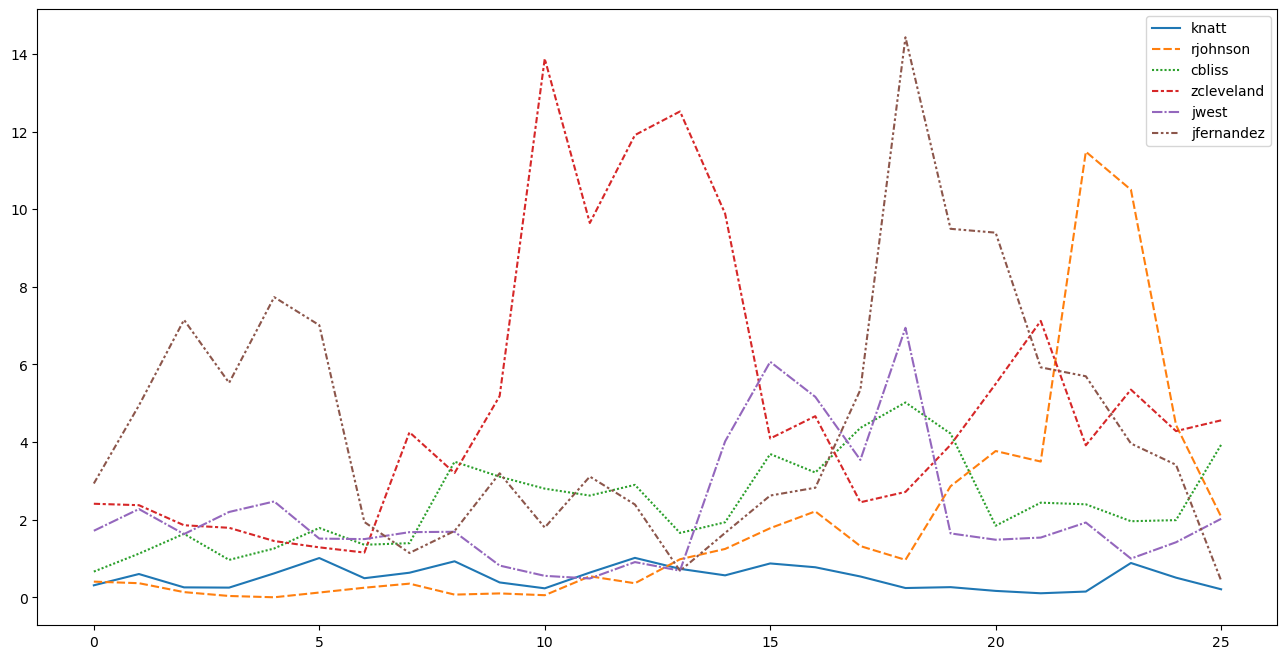

In [82]:
plt.figure(figsize=(16,8))
sns.lineplot(holder_rolling)
plt.show()

In [83]:
predict_in_window('mosei-bonsu', 26, 30, zip_results, True)
# that Florida International and Liberty game are CTOURN
# https://www.sports-reference.com/cbb/players/michael-osei-bonsu-1/gamelog/2026/

                 team               opponent
10183  Missouri State            Sam Houston
10193  Missouri State       Western Kentucky
10204  Missouri State       Middle Tennessee
10214  Missouri State  Florida International
10223  Missouri State                Liberty


,pname,season,min_total,min_pg,pts_pg,fg_made_pg,fg_attempted_pg,fg_missed_pg,tp_made_pg,tp_attempted_pg,...,fg_percentage_pg,tp_percentage_pg,ft_percentage_pg,in_conference_rate,eff_pg,team_min_pg,team_fga_pg,team_fta_pg,team_tov_pg,usg_pct
0,mosei-bonsu,2025-26,163,32.6,19.8,8.6,12.2,3.6,0.0,0.0,...,0.704918,0.0,0.565217,1.0,23.8,203.733333,54.8,22.466667,9.2,27.445692


0    34.420582
dtype: float64

### Games-To-Date

In [84]:
window_size = 1
all_player_names = test_boxscores['pname'].unique()
holder_gtd = {}

a = 1
b = 31 - window_size

for i in range (a,b):
    print("Game",a,"to Game",i+window_size)

for p in all_player_names:
    holder_gtd[p] = []
    for i in range (a,b):
        holder_gtd[p].append(predict_in_window(p, a, i+window_size, zip_results)[0])

Game 1 to Game 2
Game 1 to Game 3
Game 1 to Game 4
Game 1 to Game 5
Game 1 to Game 6
Game 1 to Game 7
Game 1 to Game 8
Game 1 to Game 9
Game 1 to Game 10
Game 1 to Game 11
Game 1 to Game 12
Game 1 to Game 13
Game 1 to Game 14
Game 1 to Game 15
Game 1 to Game 16
Game 1 to Game 17
Game 1 to Game 18
Game 1 to Game 19
Game 1 to Game 20
Game 1 to Game 21
Game 1 to Game 22
Game 1 to Game 23
Game 1 to Game 24
Game 1 to Game 25
Game 1 to Game 26
Game 1 to Game 27
Game 1 to Game 28
Game 1 to Game 29
Game 1 to Game 30


In [85]:
holder_rolling_df = pd.DataFrame.from_dict(holder_rolling)
holder_rolling_df_ranked = holder_rolling_df.rank(axis=1, ascending=False)

In [86]:
holder_gtd_df = pd.DataFrame.from_dict(holder_gtd)
holder_gtd_df_ranked = holder_gtd_df.rank(axis=1, ascending=False)

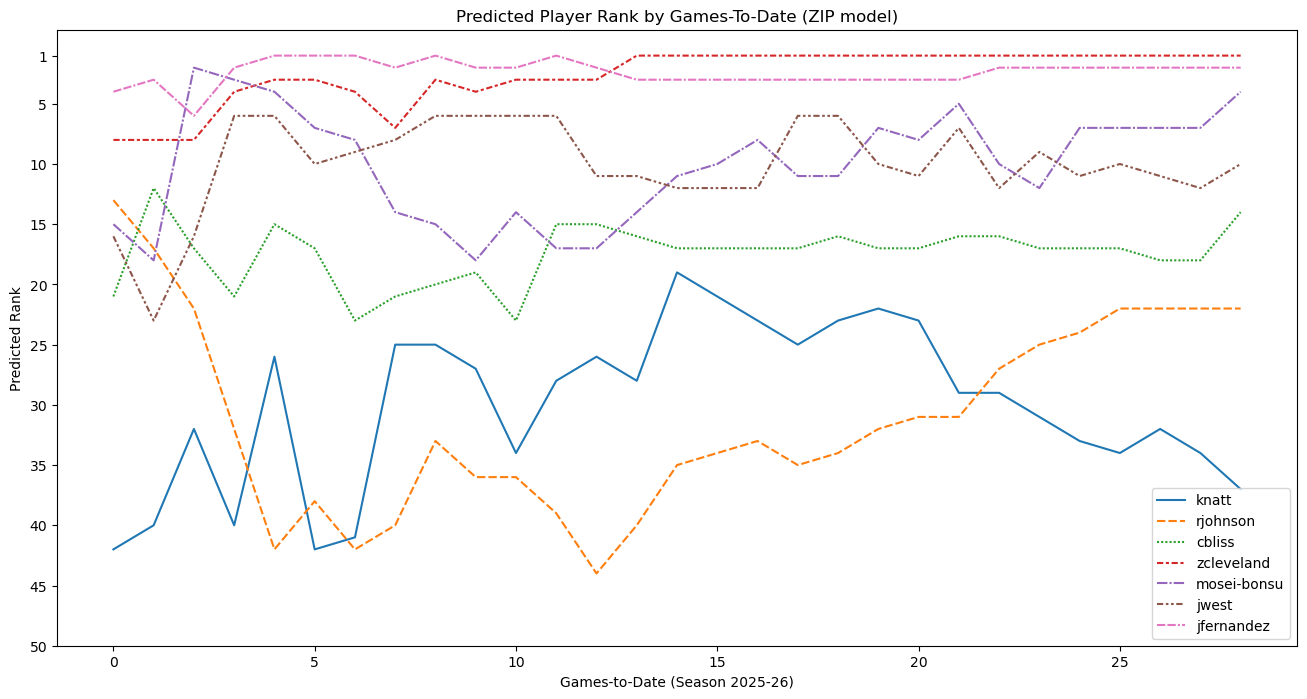

In [87]:
target_players = ['knatt',
                  'rjohnson',
                  'cbliss',
                  'zcleveland',
                  'mosei-bonsu',
                  'jwest', # one of our highest predicted not winners
                  'jfernandez', #second highest predicted not winner
                  ]

plt.figure(figsize=(16,8))
myplot = sns.lineplot(holder_gtd_df_ranked[target_players])
myplot.invert_yaxis()
myplot.set_yticks([1,5,10,15,20,25,30,35,40,45,50])
myplot.set_ylabel("Predicted Rank")
myplot.set_xlabel("Games-to-Date (Season 2025-26)")
myplot.set_title("Predicted Player Rank by Games-To-Date (ZIP model)")
plt.show()

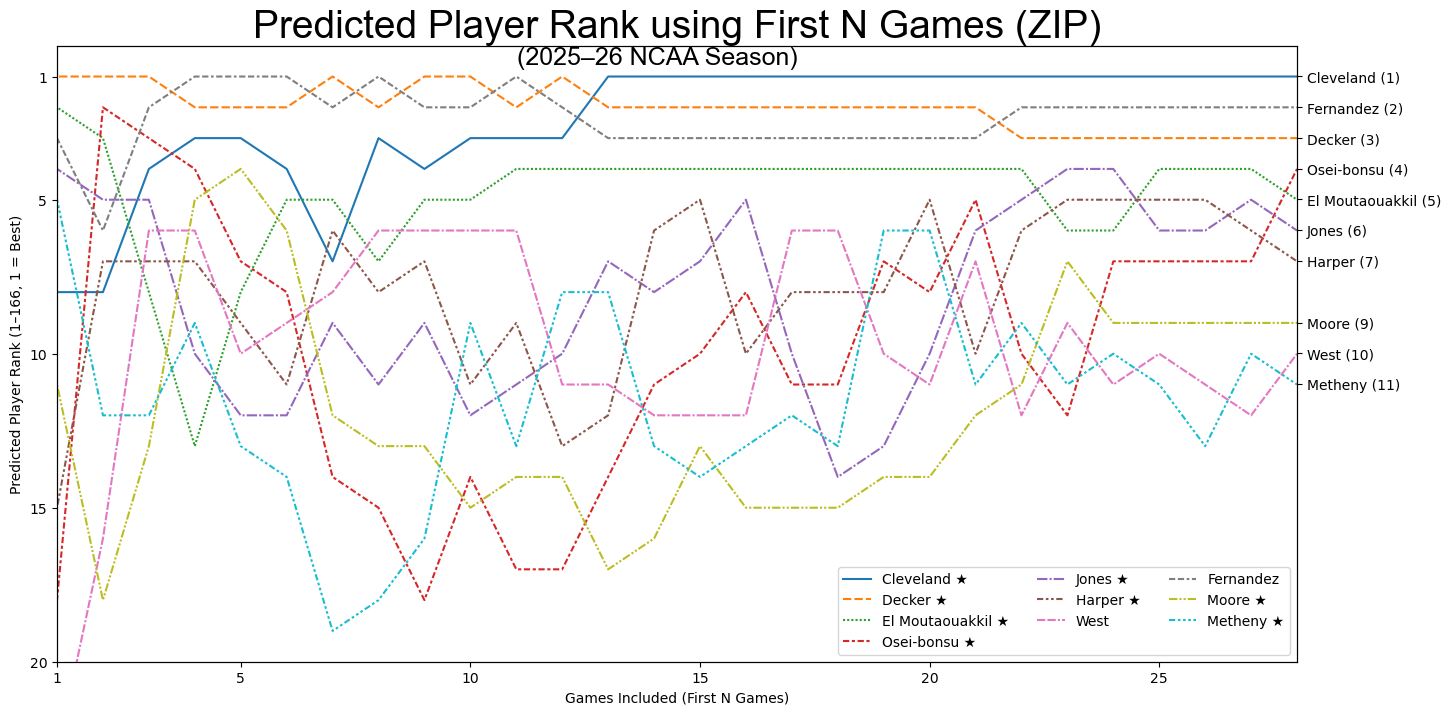

In [88]:
top_10_predicted = prediction_ranks[:10]['pname']
winners = list(test_full_season[test_full_season['award_count'] > 0]['pname'])

plt.figure(figsize=(16,8))
myplot = sns.lineplot(holder_gtd_df_ranked[top_10_predicted])
myplot.set_yticks([1,5,10,15,20,25,30])
myplot.set_ylim([0,20])
myplot.invert_yaxis()
myplot.set_ylabel("Predicted Player Rank (1–166, 1 = Best)")
myplot.set_xlabel("Games Included (First N Games)")
myplot.set_title("Predicted Player Rank using First N Games (ZIP)", fontsize=28, fontfamily="Arial")
handles, labels = myplot.get_legend_handles_labels()
fix_names1 = [label + " ★" if label in winners else label for label in labels]
fix_names2 = [label[1:].capitalize() for label in fix_names1]
fix_names3 = ["El Moutaouakkil" + label[2:] if label.startswith("El") else label for label in fix_names2]
myplot.legend(handles, fix_names3, loc="lower right", ncol=3)
myplot.set_xlim([1,28])
myplot.set_xticks([1,5,10,15,20,25])

ax2 = myplot.twinx()
# ax2.set_yticks([1,5,10,15,20,25,30])
ax2.set_ylim([0,20])
ax2.invert_yaxis()
final_predicted_ranks = dict(holder_gtd_df_ranked[top_10_predicted].iloc[-1])
# tick_positions = list(final_predicted_ranks.values())
tick_positions = np.array(list(final_predicted_ranks.values())) -.01
tick_labels = list(final_predicted_ranks.keys())
tick_fix_names1 = [label[1:].capitalize() + f" ({int(final_predicted_ranks[label])})" for label in tick_labels]
tick_fix_names2 = ["El Moutaouakkil"+ f" ({int(final_predicted_ranks["mel"])})" if label.startswith("El") else label for label in tick_fix_names1]
tick_new_labels = [label + " ★" if label in winners else label for label in tick_fix_names2]
ax2.set_yticks(tick_positions)
ax2.set_yticklabels(tick_new_labels)

plt.suptitle(
    "(2025–26 NCAA Season)",
    fontsize=18,
    fontfamily="Arial",
    y=.88
)

plt.show()

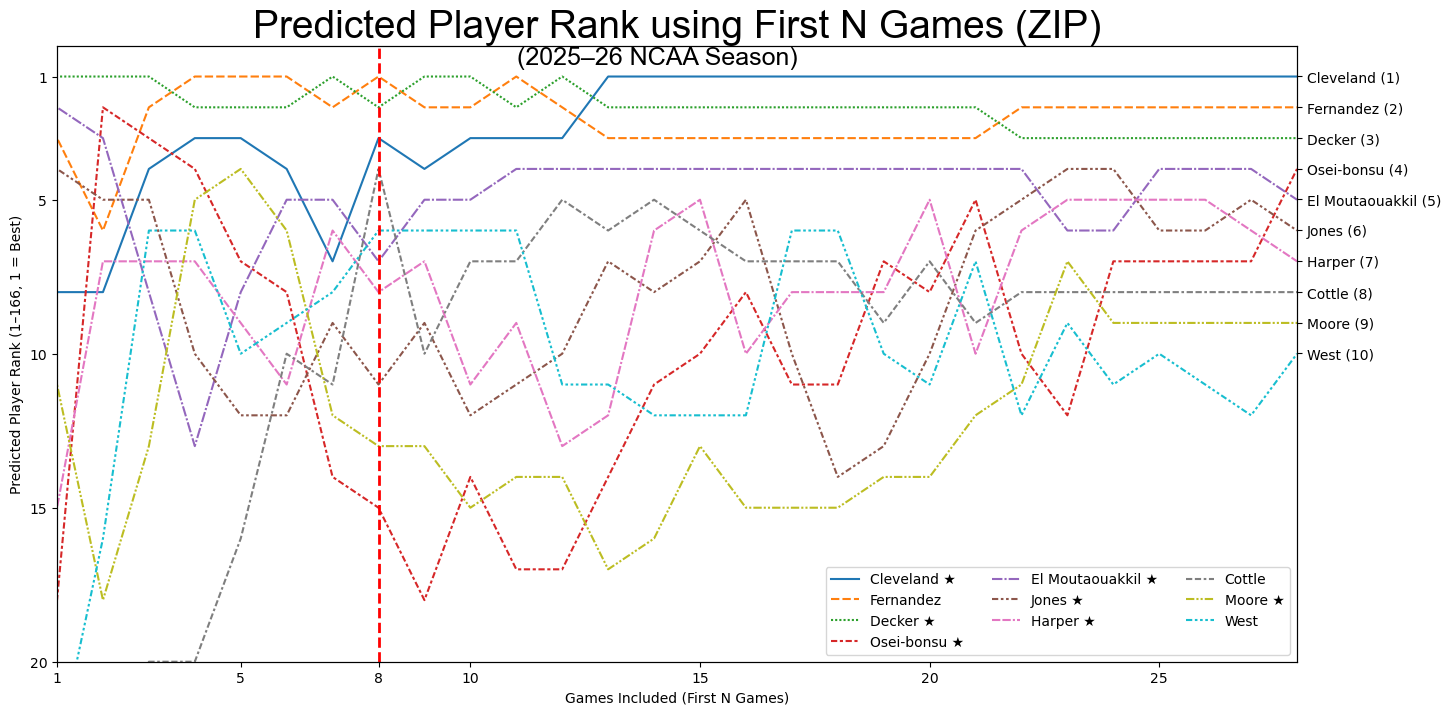

In [89]:
top_10_predicted_28 = holder_gtd_df_ranked.copy().iloc[-1].reset_index().sort_values(by=28)['index'][:10]
winners = list(test_full_season[test_full_season['award_count'] > 0]['pname'])

plt.figure(figsize=(16,8))
myplot = sns.lineplot(holder_gtd_df_ranked[top_10_predicted_28])
myplot.set_yticks([1,5,10,15,20,25,30])
myplot.set_ylim([0,20])
myplot.invert_yaxis()
myplot.set_ylabel("Predicted Player Rank (1–166, 1 = Best)")
myplot.set_xlabel("Games Included (First N Games)")
myplot.set_title("Predicted Player Rank using First N Games (ZIP)", fontsize=28, fontfamily="Arial")
handles, labels = myplot.get_legend_handles_labels()
fix_names1 = [label + " ★" if label in winners else label for label in labels]
fix_names2 = [label[1:].capitalize() for label in fix_names1]
fix_names3 = ["El Moutaouakkil" + label[2:] if label.startswith("El") else label for label in fix_names2]
myplot.legend(handles, fix_names3, loc="lower right", ncol=3)
myplot.set_xlim([1,28])
myplot.set_xticks([1,5,8,10,15,20,25])

ax2 = myplot.twinx()
# ax2.set_yticks([1,5,10,15,20,25,30])
ax2.set_ylim([0,20])
ax2.invert_yaxis()
final_predicted_ranks = dict(holder_gtd_df_ranked[top_10_predicted_28].iloc[-1])
# tick_positions = list(final_predicted_ranks.values())
tick_positions = np.array(list(final_predicted_ranks.values())) -.01
tick_labels = list(final_predicted_ranks.keys())
tick_fix_names1 = [label[1:].capitalize() + f" ({int(final_predicted_ranks[label])})" for label in tick_labels]
tick_fix_names2 = ["El Moutaouakkil"+ f" ({int(final_predicted_ranks["mel"])})" if label.startswith("El") else label for label in tick_fix_names1]
tick_new_labels = [label + " ★" if label in winners else label for label in tick_fix_names2]
ax2.set_yticks(tick_positions)
ax2.set_yticklabels(tick_new_labels)

myplot.axvline(8, color='red', linestyle='--', linewidth=2, label='Age 18')

plt.suptitle(
    "(2025–26 NCAA Season)",
    fontsize=18,
    fontfamily="Arial",
    y=.88
)

plt.show()

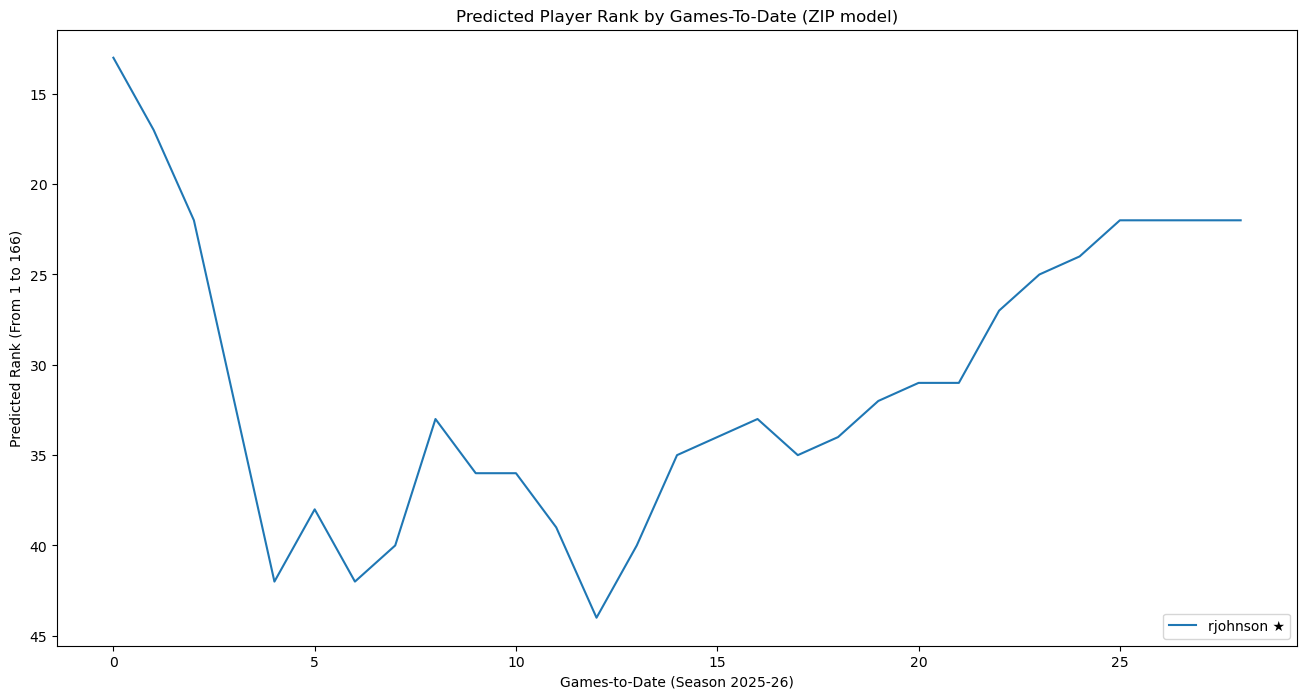

In [90]:
plt.figure(figsize=(16,8))
myplot = sns.lineplot(holder_gtd_df_ranked[['rjohnson']])
# myplot.set_ylim([0,30])
myplot.invert_yaxis()
# myplot.set_yticks([1,5,10,15,20,25,30])
myplot.set_ylabel("Predicted Rank (From 1 to 166)")
myplot.set_xlabel("Games-to-Date (Season 2025-26)")
myplot.set_title("Predicted Player Rank by Games-To-Date (ZIP model)")
handles, labels = myplot.get_legend_handles_labels()
new_labels = [label + " ★" if label in winners else label for label in labels]
myplot.legend(handles, new_labels, loc="lower right", ncol=2)
# myplot.set_xlim([1,28])
plt.show()

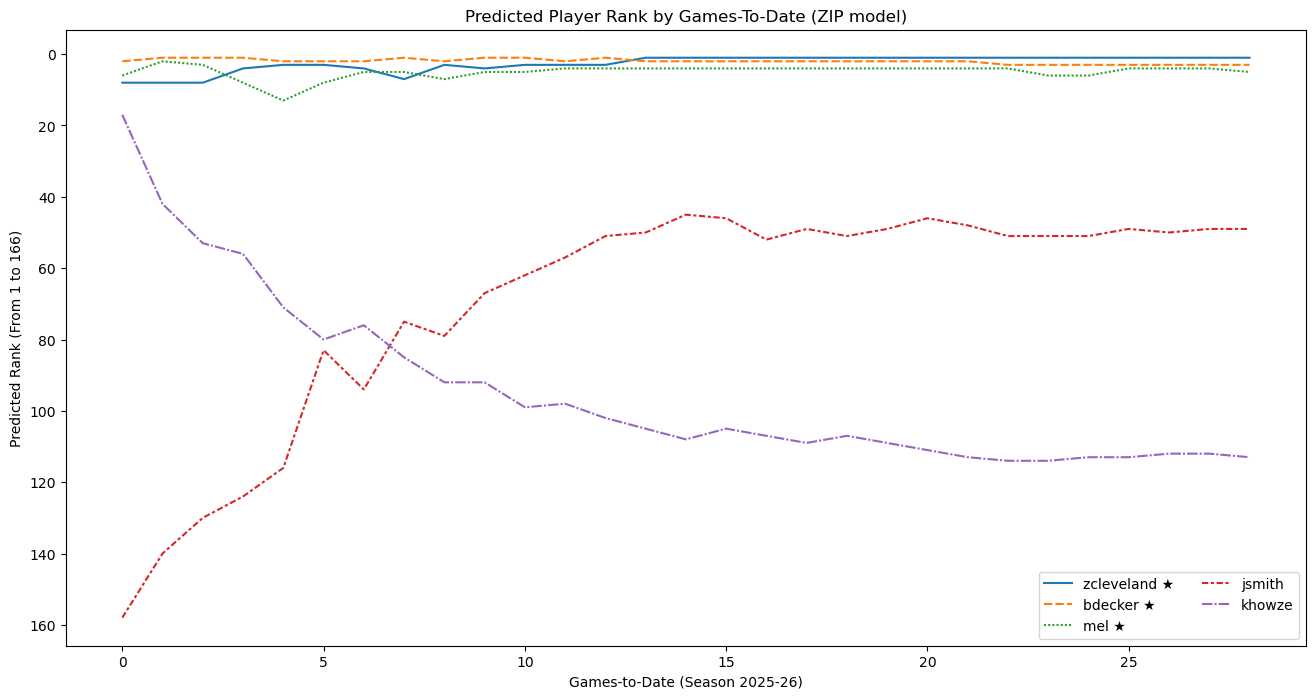

In [91]:
plt.figure(figsize=(16,8))
myplot = sns.lineplot(holder_gtd_df_ranked[['zcleveland', 'bdecker', 'mel', 'jsmith', 'khowze']])
# myplot.set_ylim([0,30])
myplot.invert_yaxis()
# myplot.set_yticks([1,5,10,15,20,25,30])
myplot.set_ylabel("Predicted Rank (From 1 to 166)")
myplot.set_xlabel("Games-to-Date (Season 2025-26)")
myplot.set_title("Predicted Player Rank by Games-To-Date (ZIP model)")
handles, labels = myplot.get_legend_handles_labels()
new_labels = [label + " ★" if label in winners else label for label in labels]
myplot.legend(handles, new_labels, loc="lower right", ncol=2)
# myplot.set_xlim([1,28])
plt.show()

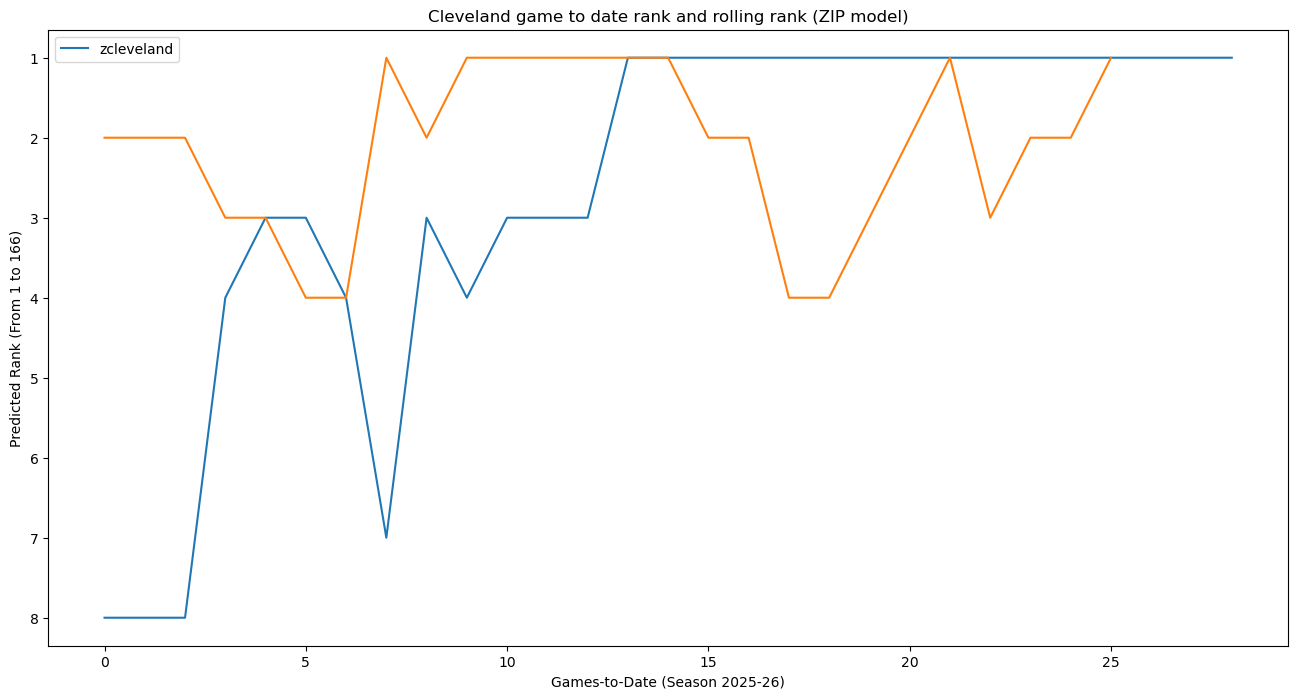

In [92]:
plt.figure(figsize=(16,8))
myplot = sns.lineplot(holder_gtd_df_ranked[['zcleveland']])
# myplot.set_ylim([0,30])
myplot.invert_yaxis()
# myplot.set_yticks([1,5,10,15,20,25,30])
myplot.set_ylabel("Predicted Rank (From 1 to 166)")
myplot.set_xlabel("Games-to-Date (Season 2025-26)")
myplot.set_title("Cleveland game to date rank and rolling rank (ZIP model)")
handles, labels = myplot.get_legend_handles_labels()
new_labels = [label + " ★" if label in winners else label for label in labels]
myplot.legend(handles, new_labels, loc="lower right", ncol=2)
# myplot.set_xlim([1,28])
sns.lineplot(holder_rolling_df_ranked['zcleveland'])
plt.show()

In [93]:
biggest_fall = holder_gtd_df_ranked.copy().transpose()
biggest_fall = biggest_fall.reset_index()
for guy in biggest_fall['index']:
    print(guy, int(biggest_fall[biggest_fall['index'] == guy][0] - biggest_fall[biggest_fall['index'] == guy][28]), "*")

edibami 41 *
lolayinka -19 *
zjackson -34 *
awilliamson 87 *
cstephenson 47 *
oibrahim -27 *
kbrown -57 *
tsucatzky -21 *
bharris 22 *
rruiz -19 *
animmers -13 *
jmackey 37 *
holayinka 25 *
aclinton -11 *
eerkins-ford 28 *
jhill 3 *
mel 1 *
abryant 15 *
jnash -13 *
adriggers -14 *
ttut -18 *
aanabitarte -19 *
cloy -31 *
bvungo 4 *
tnnadozie -65 *
jfranklin -67 *
mfitzgerald -9 *
iniagu 43 *
khowze -96 *
athomas -32 *
wallen 15 *
kcooper 3 *
abates 29 *
sherron 33 *
wjeffress 9 *
mmartinez 8 *
ddudley 60 *
jfenner -54 *
swilliams 20 *
lthompson -17 *
krowell 19 *
janderson 7 *
zcleveland 7 *
bdecker -1 *
jharper 29 *
cporter -9 *
kmetheny 21 *
rjones -37 *
bkester 3 *
tsorensen -16 *
dgrimes -16 *
tdrain -3 *
zyates -19 *
zcarter 30 *
jshirer -4 *
jsmith 109 *
iihnen -7 *
cloofe -21 *
talston 52 *
ssmith 30 *
tgreen -3 *
klands -11 *
jhall -37 *
ljovanovic -12 *
swykle 9 *
jdent -59 *
mwhitlock 35 *
jcarter -26 *
aoglesby -16 *
jmims 9 *
cmalonga -71 *
gpickens 16 *
jjones -3 *
awrzeszc

C:\Users\charl\AppData\Local\Temp\ipykernel_32072\385511446.py:4: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(guy, int(biggest_fall[biggest_fall['index'] == guy][0] - biggest_fall[biggest_fall['index'] == guy][28]), "*")


biggest falls:
- khowze	-96
- psmith	-73
- cmalonga	-71
- jfranklin	-67
- tnnadozie	-65
- dtubek	-65
biggest climbs
- cblackwell	59
- ddudley	60
- blue	61
- jharris	71
- awilliamson	87
- pking	99
- jsmith	109

### second half

In [94]:
window_size = 1

target_players = ['knatt',
                  'rjohnson',
                  'cbliss',
                  'zcleveland',
                  'mosei-bonsu',
                  'jwest', # one of our highest predicted not winners
                  'jfernandez', #second highest predicted not winner
                  ]
holder_gtd_backhalf = {}

a = 1
b = 31 - window_size

for i in range (a,b):
    print("Game",a,"to Game",i+window_size)

for p in target_players:
    holder_gtd_backhalf[p] = []
    for i in range (a,b):
        holder_gtd_backhalf[p].append(predict_in_window(p, a, i+window_size, zip_results)[0])

Game 1 to Game 2
Game 1 to Game 3
Game 1 to Game 4
Game 1 to Game 5
Game 1 to Game 6
Game 1 to Game 7
Game 1 to Game 8
Game 1 to Game 9
Game 1 to Game 10
Game 1 to Game 11
Game 1 to Game 12
Game 1 to Game 13
Game 1 to Game 14
Game 1 to Game 15
Game 1 to Game 16
Game 1 to Game 17
Game 1 to Game 18
Game 1 to Game 19
Game 1 to Game 20
Game 1 to Game 21
Game 1 to Game 22
Game 1 to Game 23
Game 1 to Game 24
Game 1 to Game 25
Game 1 to Game 26
Game 1 to Game 27
Game 1 to Game 28
Game 1 to Game 29
Game 1 to Game 30


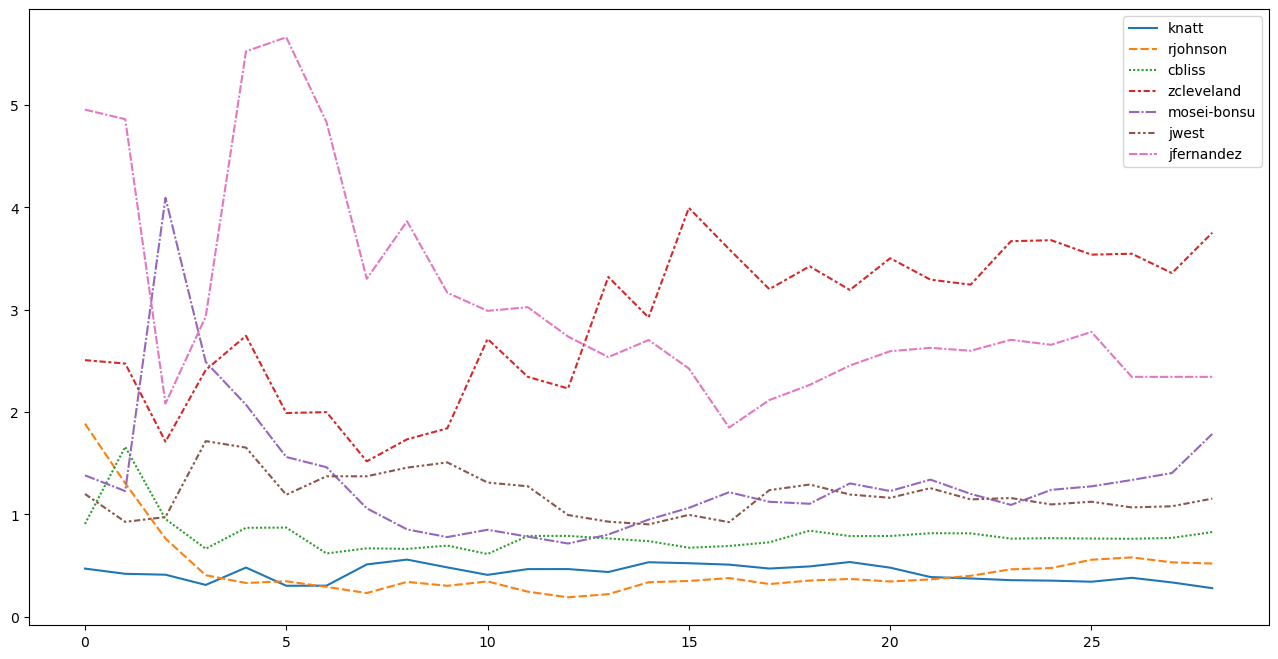

In [95]:
plt.figure(figsize=(16,8))
sns.lineplot(holder_gtd_backhalf)
plt.show()

### Actual v Predicted

In [96]:
df = pd.DataFrame()
df['Award_Count'] = y_test
df['predicted_awards'] = yhat_mean
df['poisson_predicts'] = reg_models['Poisson'].predict(X_test_full_scaled)
df['player'] = test_full_season['pname']

<Axes: xlabel='Award_Count', ylabel='predicted_awards'>

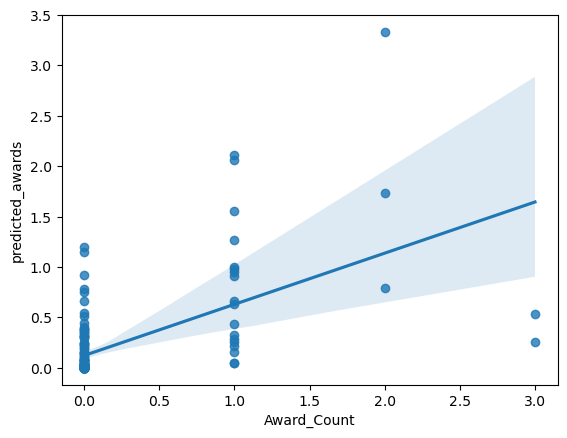

In [97]:
sns.regplot(data=df, x='Award_Count', y='predicted_awards')

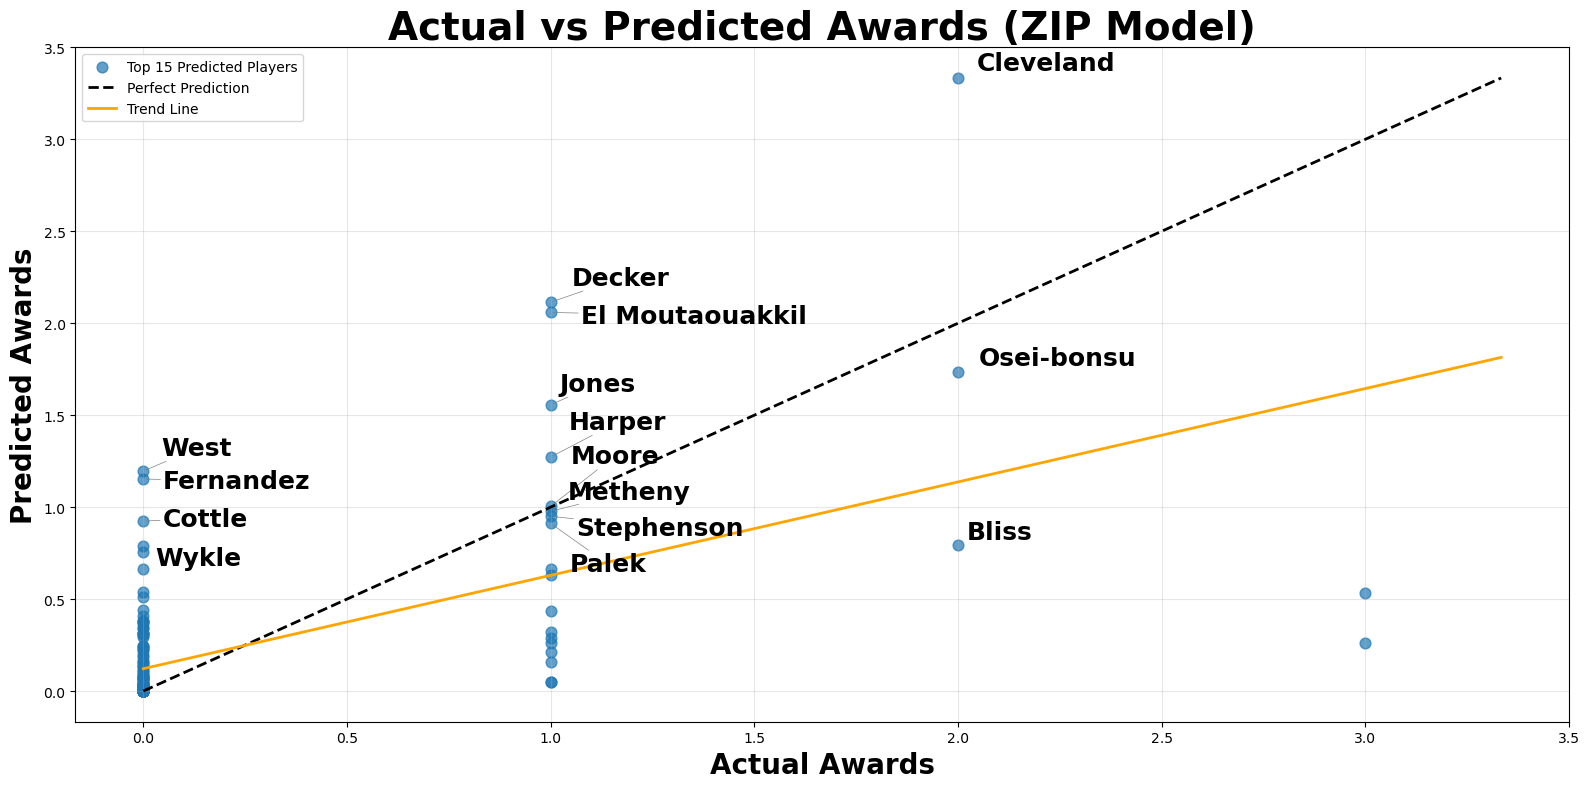

In [98]:
plt.figure(figsize=(16, 8))

m, b = np.polyfit(df['Award_Count'], df['predicted_awards'], 1)

# scatter
plt.scatter(
    df['Award_Count'],
    df['predicted_awards'],
    alpha=0.7,
    s=60,
    label='Top 15 Predicted Players'
)

# 45-degree line
min_val = min(df['Award_Count'].min(), df['predicted_awards'].min())
max_val = max(df['Award_Count'].max(), df['predicted_awards'].max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    color='black',
    label='Perfect Prediction'
)

x_vals = np.array([min_val, max_val])
y_vals = m * x_vals + b

# trend line
x_vals = np.array([min_val, max_val])
y_vals = m * x_vals + b
plt.plot(
    x_vals,
    y_vals,
    linewidth=2,
    color='orange',
    label='Trend Line'
)

# label top players
top_players = df.sort_values(by='predicted_awards', ascending=False).head(15).copy()

# top_players['pretty_name'] = [label + " ★" if label in winners else label for label in top_players['player']]
top_players['pretty_name'] = [label[1:].capitalize() for label in top_players['player']]
top_players['pretty_name'] = ["El Moutaouakkil" + label[2:] if label.startswith("El") else label for label in top_players['pretty_name']]

texts = []
for i in range(len(top_players)):
    actual = top_players['Award_Count'].iloc[i]
    pred = top_players['predicted_awards'].iloc[i]
    name = top_players['pretty_name'].iloc[i]

    texts.append(
        plt.text(
            actual,
            pred,
            name,
            fontsize=18,
            fontweight='bold'
        )
    )

# fix overlapping labels
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

plt.xlabel("Actual Awards", fontsize=20, fontweight='bold')
plt.ylabel("Predicted Awards", fontsize=20, fontweight='bold')
plt.title("Actual vs Predicted Awards (ZIP Model)", fontsize=28, fontweight='bold')

plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: xlabel='eff_pg', ylabel='yhat'>

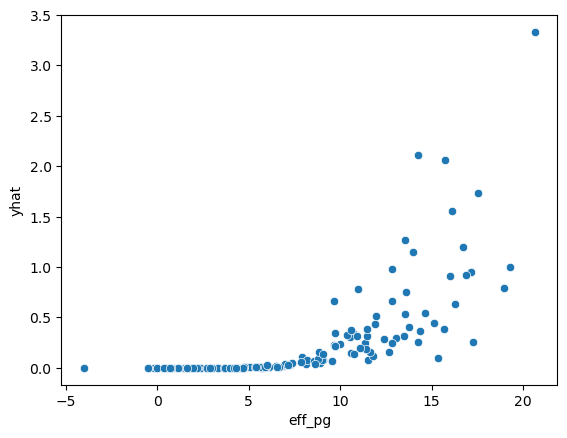

In [99]:
sns.scatterplot(data=test_full_season, x='eff_pg', y='yhat')

<Axes: xlabel='yhat', ylabel='resid'>

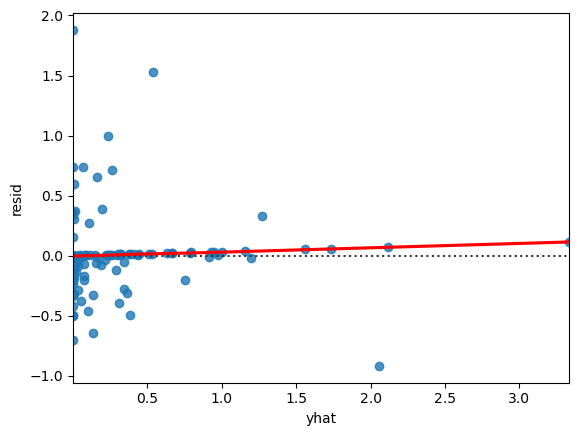

In [100]:
resid = test_full_season[['yhat']].copy()
resid['resid'] = zip_results.resid
sns.residplot(data=resid, y='resid', x='yhat', lowess=True, line_kws=dict(color="r"))

### Other

In [101]:
mask_winner = test_full_season['award_count'] > 1
test_full_season[mask_winner][['pname', 'award_count', 'yhat']].sort_values(by='award_count', ascending=False)

,pname,award_count,yhat
100,knatt,3.0,0.260086
132,rjohnson,3.0,0.533064
30,cbliss,2.0,0.794043
124,mosei-bonsu,2.0,1.733371
162,zcleveland,2.0,3.333688


In [102]:
# what is our biggest predicited non award winner
mask_no_awards = test_full_season['award_count'] == 0
mask_positive_yhat = test_full_season['yhat'] > 1
test_full_season[mask_no_awards & mask_positive_yhat][['pname','team','yhat']].sort_values(by='yhat', ascending=False)

,pname,team,yhat
93,jwest,UTEP,1.195921
75,jfernandez,Delaware,1.153132


# Misc. Helpers

## Generate model string

In [103]:
predictors = X_train_scaled_df.columns.tolist()
formula = "award_count ~ " + " + ".join(predictors)
print(formula)

award_count ~ dreb_pg + oreb_pg + ast_pg + stl_pg + blk_pg + fg_attempted_pg + fg_made_pg + ft_attempted_pg + ft_made_pg + tov_pg + team_fga_pg + team_fta_pg + team_tov_pg
